In [46]:
import numpy as np 
import matplotlib.pyplot as plt
import OrcFxAPI
import h5py
import pandas as pd
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar



In [47]:
model_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Decay_opzet_harlequin_V3.dat"
exp_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\002\34224_03CB_02_002_006_01_Decay1.h5m"

lookback_window = 5.0      # seconden vóór decay-start waarin we de amplitude zoeken
quiet_window_end = 12.0     # rustige periode eindigt 12 s vóór decay-start
quiet_window_length = 50.0


In [48]:
def run_decay_case(model_path, A0, exp_time, exp_signal, delta_t_exp,
                   linear_damping, quadratic_damping):
    """
    Draait 1 OrcaFlex decay case en vergelijkt met experiment.
    """

    # -------------------------
    # model opnieuw openen
    # -------------------------
    model = OrcFxAPI.Model(model_path)
    constraint = model["decay_constraint"]
    floaters = model["floaters"]
    floatertype = model["Floatertype"]

    # -------------------------
    # beginverplaatsing zetten
    # -------------------------


    # -------------------------
    constraint.InFrameInitialZ = A0
    constraint.InFrameInitialX = 0
    constraint.InFrameInitialY = 0
    constraint.InFrameInitialAzimuth = 0
    constraint.InFrameInitialDeclination = 0 
    constraint.InFrameInitialGamma = 0

    floatertype.OtherDampingLinearCoeffx = 0 #surge
    floatertype.OtherDampingLinearCoeffy = 0 #sway
    floatertype.OtherDampingLinearCoeffz  = linear_damping
    floatertype.OtherDampingLinearCoeffRx = 0 #roll
    floatertype.OtherDampingLinearCoeffRy = 0 #pitch
    floatertype.OtherDampingLinearCoeffRz = 0 #yaw

    floatertype.OtherDampingQuadraticCoeffx = 0 #surge
    floatertype.OtherDampingQuadraticCoeffy = 0 #sway 
    floatertype.OtherDampingQuadraticCoeffz = quadratic_damping #heav
    floatertype.OtherDampingQuadraticCoeffRx = 0#roll
    floatertype.OtherDampingQuadraticCoeffRy = 0 #pitch
    floatertype.OtherDampingQuadraticCoeffRz = 0 #yaw
        # run
    # -------------------------
    model.RunSimulation()

    
    t_sim = model.general.TimeHistory("Time")
    z_sim = floaters.TimeHistory("Z")

    # -------------------------
    # tijd verschuiven met experimenteel verschil
    # -------------------------
    t_sim_decay = t_sim - t_sim[0]
    t_sim_shifted = t_sim_decay - delta_t_exp

    # -------------------------
    # interpolatiefunctie
    # -------------------------
    f_sim = interp1d(
        t_sim_shifted,
        z_sim,
        bounds_error=False,
        fill_value=np.nan
    )

    # -------------------------
    # kleine extra shift fitten
    # -------------------------
    def compute_rmse(time_shift):
        z_sim_trial = f_sim(exp_time + time_shift)
        mask = ~np.isnan(z_sim_trial)

        if np.sum(mask) < 10:
            return 1e9

        error = z_sim_trial[mask] - exp_signal[mask]
        return np.sqrt(np.mean(error**2))

    result = minimize_scalar(
        compute_rmse,
        bounds=(-2.0, 2.0),
        method="bounded"
    )

    best_shift = result.x
    z_sim_fit = f_sim(exp_time + best_shift)

    mask = ~np.isnan(z_sim_fit)

    error = z_sim_fit[mask] - exp_signal[mask]
    rmse = np.sqrt(np.mean(error**2))
    mae = np.mean(np.abs(error))

    return {
        "linear_damping": linear_damping,
        "quadratic_damping": quadratic_damping,
        "best_time_shift": best_shift,
        "rmse": rmse,
        "mae": mae,
        "t_sim_shifted": t_sim_shifted,
        "z_sim": z_sim,
        "z_sim_fit": z_sim_fit,
        "mask": mask,
    }

In [49]:
with h5py.File(exp_path, "r") as f:
    t_exp = f["CroppedSignals/time"][:]
    z_exp = f["CroppedSignals/Z_COG (LPF: 5.0 rad*s^-1)"][:]
    t_unfiltered = f["UnfilteredSignals/time"][:]
    z_unfiltered = f["UnfilteredSignals/Z_COG (unfiltered)"][:]

# DataFrames in één keer maken
df_exp = pd.DataFrame({
    "time [s]": t_exp,
    "time_norm [s]": t_exp - t_exp[0],
    "z_exp [m]": z_exp
})

df_unfiltered = pd.DataFrame({
    "time [s]": t_unfiltered,
    "z_unfiltered [m]": z_unfiltered
})


In [50]:
t_decay_start = t_exp[0]

# -----------------------------
# 2. rustige periode in ongefilterd signaal kiezen
#    van (start - quiet_window_end - quiet_window_length) tot (start - quiet_window_end)
# -----------------------------
quiet_start = t_decay_start - quiet_window_end - quiet_window_length
quiet_end = t_decay_start - quiet_window_end

mask_quiet = (t_unfiltered >= quiet_start) & (t_unfiltered <= quiet_end)

if not np.any(mask_quiet):
    raise ValueError("Geen data gevonden in de gekozen rustige periode. Kies andere vensters.")

z_eq = np.mean(z_unfiltered[mask_quiet])

# -----------------------------
# 3. zoekvenster voor initiële amplitude
#    10 s vóór decay-start
# -----------------------------
search_start = t_decay_start - lookback_window
search_end = t_decay_start

mask_search = (t_unfiltered >= search_start) & (t_unfiltered <= search_end)

if not np.any(mask_search):
    raise ValueError("Geen data gevonden in het zoekvenster vóór de decay-start.")

t_search = t_unfiltered[mask_search]
z_search = z_unfiltered[mask_search]

# afwijking t.o.v. evenwicht
deviation = z_search - z_eq

# index van grootste absolute uitslag
idx_local = np.argmax(np.abs(deviation))

t_init = t_search[idx_local]
z_init = z_search[idx_local]
A0 = np.abs(z_init - z_eq)

delta_t_exp = t_decay_start - t_init
t_exp_decay = t_exp - t_decay_start

print(f"Decay start time           = {t_decay_start:.3f} s")
print(f"Quiet window               = [{quiet_start:.3f}, {quiet_end:.3f}] s")
print(f"Equilibrium level z_eq     = {z_eq:.6f} m")
print(f"Search window              = [{search_start:.3f}, {search_end:.3f}] s")
print(f"Initial extreme at t       = {t_init:.3f} s")
print(f"Initial extreme z          = {z_init:.6f} m")
print(f"Initial amplitude A0       = {A0:.6f} m")
print(f"Signed amplitude           = {z_init - z_eq:.6f} m")

Decay start time           = 1087.008 s
Quiet window               = [1025.008, 1075.008] s
Equilibrium level z_eq     = 0.021210 m
Search window              = [1082.008, 1087.008] s
Initial extreme at t       = 1082.033 s
Initial extreme z          = -3.157819 m
Initial amplitude A0       = 3.179029 m
Signed amplitude           = -3.179029 m


In [51]:
target_rmse = 0.20
target_mae = 0.15

c_lin = 3
c_quad =2
step_lin = 0.2
step_quad = 0.2

min_step_lin = 0.05
min_step_quad = 0.05

max_iter = 4

result = run_decay_case(
    model_path=model_path,
    A0=A0,
    exp_time=t_exp_decay,
    exp_signal=z_exp,
    delta_t_exp=delta_t_exp,
    linear_damping=c_lin,
    quadratic_damping=c_quad
)

print("RMSE =", result["rmse"])
print("MAE  =", result["mae"])



RMSE = 1.1008348861702721
MAE  = 0.930900916939132


In [52]:
def evaluate_case(c_lin, c_quad):
    result = run_decay_case(
        model_path=model_path,
        A0=A0,
        exp_time=t_exp_decay,
        exp_signal=z_exp,
        delta_t_exp=delta_t_exp,
        linear_damping=c_lin,
        quadratic_damping=c_quad
    )
    return result

In [53]:
def try_neighbours(c_lin, c_quad, step_lin, step_quad):
    candidates = [
        (c_lin, c_quad),
        (max(0.0, c_lin + step_lin), c_quad),
        (max(0.0, c_lin - step_lin), c_quad),
        (c_lin, max(0.0, c_quad + step_quad)),
        (c_lin, max(0.0, c_quad - step_quad)),
        (max(0.0, c_lin + step_lin), max(0.0, c_quad + step_quad)),
        (max(0.0, c_lin + step_lin), max(0.0, c_quad - step_quad)),
        (max(0.0, c_lin - step_lin), max(0.0, c_quad + step_quad)),
        (max(0.0, c_lin - step_lin), max(0.0, c_quad - step_quad)),
    ]

    results = []

    for lin, quad in candidates:
        res = evaluate_case(lin, quad)
        results.append({
            "linear_damping": lin,
            "quadratic_damping": quad,
            "rmse": res["rmse"],
            "mae": res["mae"],
            "best_time_shift": res["best_time_shift"],
            "z_sim_fit": res["z_sim_fit"]
        })

    return results

In [54]:
def pick_best(results):
    df = pd.DataFrame(results)
    df = df.sort_values(["rmse", "mae"]).reset_index(drop=True)
    return df

In [55]:
history = []

for i in range(max_iter):
    print(f"\nIteratie {i+1}")
    print(f"Huidig: c_lin={c_lin}, c_quad={c_quad}, step_lin={step_lin}, step_quad={step_quad}")

    neighbour_results = try_neighbours(c_lin, c_quad, step_lin, step_quad)
    df_iter = pick_best(neighbour_results)

    best = df_iter.iloc[0]

    history.append(best.to_dict())

    print(f"Beste kandidaat: c_lin={best['linear_damping']}, c_quad={best['quadratic_damping']}")
    print(f"RMSE={best['rmse']:.6f}, MAE={best['mae']:.6f}")

    # stopcriterium
    if best["rmse"] <= target_rmse and best["mae"] <= target_mae:
        print("Doel gehaald.")
        c_lin = best["linear_damping"]
        c_quad = best["quadratic_damping"]
        break

    # als beste kandidaat gelijk blijft aan huidige punt -> stappen kleiner maken
    if best["linear_damping"] == c_lin and best["quadratic_damping"] == c_quad:
        step_lin /= 2.0
        step_quad /= 2.0
        print("Geen verbetering gevonden, stapgrootte gehalveerd.")

        if step_lin < min_step_lin and step_quad < min_step_quad:
            print("Stapgrootte te klein geworden, stoppen.")
            break
    else:
        c_lin = best["linear_damping"]
        c_quad = best["quadratic_damping"]


Iteratie 1
Huidig: c_lin=1, c_quad=1, step_lin=0.2, step_quad=0.2
Beste kandidaat: c_lin=1.2, c_quad=1.2
RMSE=1.011804, MAE=0.845312

Iteratie 2
Huidig: c_lin=1.2, c_quad=1.2, step_lin=0.2, step_quad=0.2
Beste kandidaat: c_lin=1.4, c_quad=1.4
RMSE=0.938716, MAE=0.774649

Iteratie 3
Huidig: c_lin=1.4, c_quad=1.4, step_lin=0.2, step_quad=0.2
Beste kandidaat: c_lin=1.5999999999999999, c_quad=1.5999999999999999
RMSE=0.877865, MAE=0.715544

Iteratie 4
Huidig: c_lin=1.5999999999999999, c_quad=1.5999999999999999, step_lin=0.2, step_quad=0.2
Beste kandidaat: c_lin=1.7999999999999998, c_quad=1.7999999999999998
RMSE=0.826667, MAE=0.665969


In [56]:
df_history = pd.DataFrame(history)
df_history

,linear_damping,quadratic_damping,rmse,mae,best_time_shift,z_sim_fit
0,1.2,1.2,1.011804,0.845312,0.573169,"[-2.2509474824749565, -2.1740836609799903, -2...."
1,1.4,1.4,0.938716,0.774649,0.586664,"[-2.1486203194570175, -2.0705532531924273, -1...."
2,1.6,1.6,0.877865,0.715544,0.597211,"[-2.0578797740949897, -1.9763297732805152, -1...."
3,1.8,1.8,0.826667,0.665969,0.607195,"[-1.9739090201902687, -1.8895136735358384, -1...."


In [57]:
best_overall = df_history.sort_values(["rmse", "mae"]).iloc[0]

print("Beste gevonden waarden:")
print("linear_damping   =", best_overall["linear_damping"])
print("quadratic_damping =", best_overall["quadratic_damping"])
print("RMSE =", best_overall["rmse"])
print("MAE  =", best_overall["mae"])

Beste gevonden waarden:
linear_damping   = 1.7999999999999998
quadratic_damping = 1.7999999999999998
RMSE = 0.8266668246271759
MAE  = 0.6659693966926817


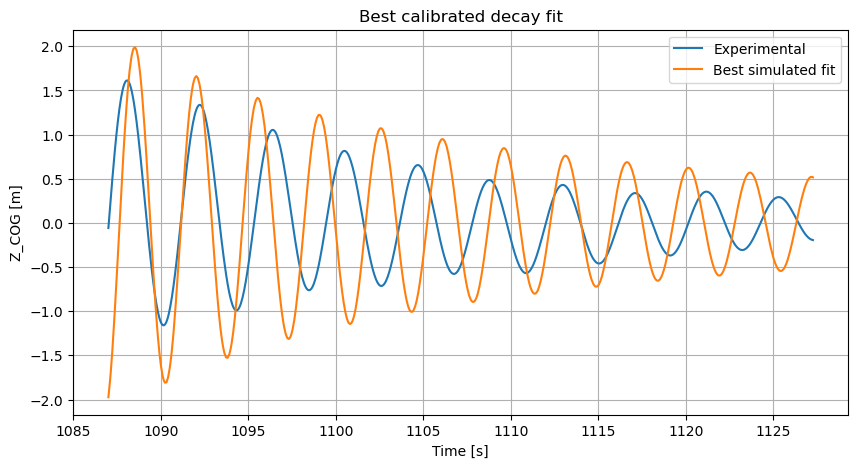

In [67]:
best_result = run_decay_case(
    model_path=model_path,
    A0=A0,
    exp_time=t_exp_decay,
    exp_signal=z_exp,
    delta_t_exp=delta_t_exp,
    linear_damping=best_overall["linear_damping"],
    quadratic_damping=best_overall["quadratic_damping"]
)

plt.figure(figsize=(10, 5))
plt.plot(t_exp, z_exp, label="Experimental")
plt.plot(t_exp, best_result["z_sim_fit"], label="Best simulated fit")

plt.xlabel("Time [s]")
plt.ylabel("Z_COG [m]")

plt.title("Best calibrated decay fit")
plt.grid(True)
plt.legend()
plt.show()

In [64]:
def estimate_period(time, signal, min_distance=0.5, prominence=0.05):
    dt = np.median(np.diff(time))
    distance = max(1, int(min_distance / dt))
    peaks, _ = find_peaks(signal, distance=distance, prominence=prominence)
    if len(peaks) < 2:
        return np.nan, peaks
    periods = np.diff(time[peaks])
    return np.mean(periods), periods

period_search, periods_search = estimate_period(t_search, z_search)
period_exp, periods_exp = estimate_period(t_exp, z_exp)
period_sim, periods_sim = estimate_period(t_exp, best_result["z_sim_fit"][best_result["mask"]])

print("Periode van z_search:", period_search, "s")
print("Periode van z_exp   :", period_exp, "s")
print("Gevonden perioden z_search:", periods_search)
print("Gevonden perioden z_exp   :", periods_exp)
print('periode simulatie   :', period_sim, "s")
print("periode experiement vs simulatie:", period_exp, "s vs", period_sim, "s")





Periode van z_search: nan s
Periode van z_exp   : 4.13354159757465 s
Gevonden perioden z_search: [43]
Gevonden perioden z_exp   : [4.12359557 4.16838848 4.12352401 4.16846004 4.0787311  4.21318139
 4.12359557 4.07880265 4.12359557]
periode simulatie   : 3.509524790375349 s
periode experiement vs simulatie: 4.13354159757465 s vs 3.509524790375349 s
